## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013



# Avance 2. Ingeniería de Características (Feature Engineering)



## Índice de Ingeniería de Características

11. **Transformaciones para Reducir Asimetrías**  
    - 11.1 Diagnóstico de Sesgo  
    - 11.2 Aplicación de Transformación Yeo-Johnson  

12. **Selección de Características — Métodos de Filtrado**  
    - 12.1 Filtrado por Varianza *(sobre datos YA transformados)*  
    - 12.2 Escalamiento con StandardScaler *(sobre subconjunto filtrado)*  
    - 12.3 Clustering de Pearson usando VARIANZA *(sin usar target)*  
    - 12.4 Ranking Combinado MI+ANOVA *(con validación de divergencia Spearman)*  
    - 12.5 Construcción de los Conjuntos (FULL, CLUSTERING, FILTER, FILTER_MI / FILTER_ANOVA)  

13. **Codificación de Variables Categóricas**  
    - 13.1 Label Encoding para categóricas binarias  
    - 13.2 OneHot Encoding para categóricas nominales con más de 2 categorías  
    - 13.3 Concatenación a los Conjuntos

14. **Escalamiento** 

15. **Extracción de Características**  

16. **Matrices Finales para Modelado**  
    - 16.1 Generar y verificar las matrices  

17. **Conclusiones — Fase de Preparación de Datos (CRISP-ML)**  
    - 17.1 Selección de características  
    - 17.2 Transformaciones y preprocesamiento  
    - 17.3 Extracción de características  
    - 17.4 Matrices entregables para modelado  
    - 17.5 Referencias


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest,
    mutual_info_classif, chi2, f_classif
)
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler,
    PowerTransformer
)
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import shapiro
import scipy.cluster.hierarchy as sch

print('Librerías de FE cargadas.')

Librerías de FE cargadas.


In [3]:
import os
DIR = "D:/Proyectos/Python/pi_psoriasis/data/processed"
os.chdir(DIR)

In [4]:
df = pd.read_csv('psoriasis_preprocesado.csv')

In [5]:
VAR_OBJETIVO = 'Condition/control'

COLS_CATEGORICAS_CONOCIDAS = [VAR_OBJETIVO, 'Sex','Lesional/Non-lesional']
# Definir listas globales de columnas para usar en el resto del notebook
COLS_CATEGORICAS = [c for c in COLS_CATEGORICAS_CONOCIDAS if c != VAR_OBJETIVO]
COLS_NUMERICAS   = df.select_dtypes(include=np.number).columns.tolist()

COLORES = ['steelblue', 'tomato']

---
## 11. Transformaciones para Reducir Asimetrías

**Se aplican PRIMERO las transformaciones antes de cualquier filtrado**

**Justificación:** La transformación Yeo-Johnson puede cambiar la varianza de las variables. Por lo tanto, es necesario aplicarla ANTES del filtrado por varianza para que el filtro opere sobre los datos ya transformados y tome decisiones correctas sobre qué variables eliminar.

**Orden correcto:**
1. ✅ Yeo-Johnson (transforma distribuciones sesgadas)
2. ✅ Filtrado por varianza (sobre datos transformados)
3. ✅ Escalamiento (sobre subconjunto filtrado)

### 11.1 Diagnóstico de Sesgo

**Criterio:** Variables con |skewness| > 1.0 se consideran asimétricas y requieren transformación.

In [6]:
UMBRAL_SESGO = 1.0

# Calcular sesgo en TODAS las variables numéricas
X_num_raw = df[COLS_NUMERICAS].copy()
sesgo_dict = X_num_raw.skew().to_dict()

# Identificar variables con sesgo significativo
cols_sesgo = [col for col, skew_val in sesgo_dict.items() if abs(skew_val) > UMBRAL_SESGO]

print(f' Diagnóstico de Asimetría (Umbral = {UMBRAL_SESGO})')
print(f'   Variables con sesgo significativo: {len(cols_sesgo)} de {len(COLS_NUMERICAS)}')
print(f'\nTop 10 variables con mayor sesgo absoluto:')
top_sesgo = sorted(sesgo_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for col, skew_val in top_sesgo:
    marca = '⚠️' if abs(skew_val) > UMBRAL_SESGO else '✓'
    print(f'  {marca}  {col:45s}  skew={skew_val:>7.3f}')

# Guardar lista de variables con sesgo para aplicar transformación
print(f'\n📋 Variables que requieren transformación: {len(cols_sesgo)}')

 Diagnóstico de Asimetría (Umbral = 1.0)
   Variables con sesgo significativo: 332 de 338

Top 10 variables con mayor sesgo absoluto:
  ⚠️  CXCL6 206336_at                                skew= 23.649
  ⚠️  CXCL11 211122_s_at                             skew= 17.469
  ⚠️  CXCL1 204470_at                                skew= 16.391
  ⚠️  ELOVL3 234513_at                               skew= 15.110
  ⚠️  CXCL11 210163_at                               skew= 14.897
  ⚠️  THRSP 1553583_a_at                             skew= 13.440
  ⚠️  CXCL8 211506_s_at                              skew= 12.781
  ⚠️  IL17C 224079_at                                skew= 12.088
  ⚠️  IL1B 205067_at                                 skew= 11.098
  ⚠️  CRAT 205843_x_at                               skew= 10.877

📋 Variables que requieren transformación: 332


### 11.2 Aplicación de Transformación Yeo-Johnson

**Justificación:** Yeo-Johnson es una generalización de Box-Cox que acepta valores negativos y ceros, común en datos de expresión génica normalizados. Busca una transformación óptima (potencia λ) que aproxime cada variable a una distribución normal.

✅ Transformación Yeo-Johnson aplicada a todas las variables numéricas

Comparación de sesgo (antes vs después) - Top 10 variables con mayor mejora:
  CXCL6 206336_at                                 23.649 →  -0.070  (mejora: 23.579)
  CXCL11 211122_s_at                              17.469 →  -0.014  (mejora: 17.455)
  ELOVL3 234513_at                                15.110 →  -0.067  (mejora: 15.042)
  CXCL11 210163_at                                14.897 →  -0.016  (mejora: 14.881)
  CXCL1 204470_at                                 16.391 →  -2.524  (mejora: 13.867)
  THRSP 1553583_a_at                              13.440 →  -0.108  (mejora: 13.332)
  CXCL8 211506_s_at                               12.781 →   0.036  (mejora: 12.746)
  IL1B 205067_at                                  11.098 →  -0.017  (mejora: 11.082)
  IL17C 224079_at                                 12.088 →   1.094  (mejora: 10.994)
  CRAT 205843_x_at                                10.877 →  -0.088  (mejora: 10.788)


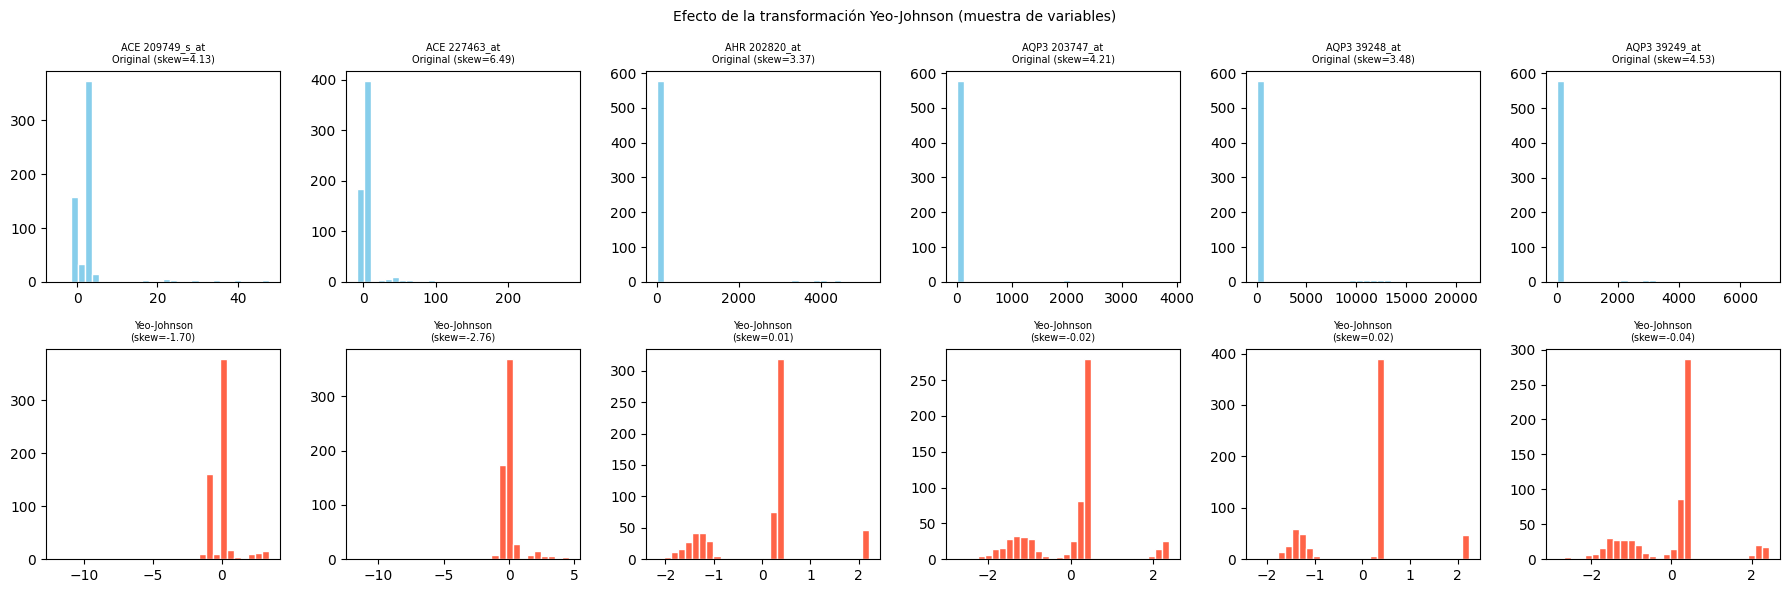

In [7]:
# Aplicar Yeo-Johnson a TODAS las variables numéricas (incluyendo las con sesgo)
pt = PowerTransformer(method='yeo-johnson')
X_num_transformed = pd.DataFrame(
    pt.fit_transform(X_num_raw.fillna(X_num_raw.median())),
    columns=X_num_raw.columns,
    index=X_num_raw.index
)

# Verificar mejora en sesgo
print('✅ Transformación Yeo-Johnson aplicada a todas las variables numéricas\n')
print('Comparación de sesgo (antes vs después) - Top 10 variables con mayor mejora:')
mejoras = []
for col in cols_sesgo:
    sesgo_antes = X_num_raw[col].skew()
    sesgo_despues = X_num_transformed[col].skew()
    mejora = abs(sesgo_antes) - abs(sesgo_despues)
    mejoras.append((col, sesgo_antes, sesgo_despues, mejora))

mejoras.sort(key=lambda x: x[3], reverse=True)
for col, antes, despues, mejora in mejoras[:10]:
    print(f'  {col:45s}  {antes:>7.3f} → {despues:>7.3f}  (mejora: {mejora:>6.3f})')

# Visualizar distribución antes vs después para las primeras 6 variables sesgadas
muestra = cols_sesgo[:6]
if muestra:
    fig, axes = plt.subplots(2, len(muestra), figsize=(len(muestra) * 3, 6))
    for i, col in enumerate(muestra):
        axes[0, i].hist(X_num_raw[col].dropna(), bins=30, color='skyblue', edgecolor='white')
        axes[0, i].set_title(f'{col}\nOriginal (skew={X_num_raw[col].skew():.2f})', fontsize=7)
        axes[1, i].hist(X_num_transformed[col], bins=30, color='tomato', edgecolor='white')
        axes[1, i].set_title(f'Yeo-Johnson\n(skew={X_num_transformed[col].skew():.2f})', fontsize=7)
    plt.suptitle('Efecto de la transformación Yeo-Johnson (muestra de variables)', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('Ninguna variable supera el umbral de sesgo definido.')

---
## 12. Selección de Características — Métodos de Filtrado

**NOTA IMPORTANTE:** Todos los filtrados se aplican DESPUÉS de la transformación Yeo-Johnson.

### 12.1 Filtrado por Varianza *(sobre datos YA transformados)*

**Justificación:** Variables con varianza cercana a cero no aportan capacidad discriminativa al modelo. Se aplica DESPUÉS de Yeo-Johnson porque la transformación puede cambiar qué variables tienen baja varianza.

In [8]:
UMBRAL_VARIANZA = 0.01

# Aplicar filtro sobre datos TRANSFORMADOS
selector_var = VarianceThreshold(threshold=UMBRAL_VARIANZA)
selector_var.fit(X_num_transformed)

cols_alta_var  = X_num_transformed.columns[selector_var.get_support()].tolist()
cols_baja_var  = X_num_transformed.columns[~selector_var.get_support()].tolist()

print(f'🔍 Filtrado por Varianza (Umbral = {UMBRAL_VARIANZA})')
print(f'   Aplicado sobre datos YA transformados con Yeo-Johnson')
print(f'\nVariables eliminadas por baja varianza ({len(cols_baja_var)}):')
for col in cols_baja_var:
    print(f'  ✗  {col:45s}  var={X_num_transformed[col].var():.6f}')

print(f'\n✅ Variables que pasan el filtro: {len(cols_alta_var)} de {len(X_num_transformed.columns)}')

COLS_NUM_FILTRADAS = cols_alta_var
X_num_filtered = X_num_transformed[COLS_NUM_FILTRADAS].copy()

🔍 Filtrado por Varianza (Umbral = 0.01)
   Aplicado sobre datos YA transformados con Yeo-Johnson

Variables eliminadas por baja varianza (0):

✅ Variables que pasan el filtro: 338 de 338


### 12.2 Escalamiento con StandardScaler *(sobre subconjunto filtrado)*

**Justificación:** Se aplica DESPUÉS del filtrado por varianza para estandarizar a media 0 y desviación estándar 1.

In [9]:
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num_filtered),
    columns=X_num_filtered.columns,
    index=X_num_filtered.index
)

print(f'✅ Escalamiento aplicado')
print(f'   Dimensiones: {X_num_scaled.shape}')
print(f'\nVerificación (media ≈ 0, std ≈ 1):')
print(X_num_scaled.describe().loc[['mean', 'std']].head(5).T)

✅ Escalamiento aplicado
   Dimensiones: (624, 338)

Verificación (media ≈ 0, std ≈ 1):
                                           mean       std
ACE 209749_s_at                   -9.109522e-17  1.000802
ACE 227463_at                     -2.277381e-17  1.000802
AHR 202820_at                      9.109522e-17  1.000802
AQP3 203747_at                     0.000000e+00  1.000802
AQP3 39248_at                      0.000000e+00  1.000802
AQP3 39249_at                      9.109522e-17  1.000802
B2M 201891_s_at                    0.000000e+00  1.000802
B2M 216231_s_at                    0.000000e+00  1.000802
B2M 232311_at                     -9.109522e-17  1.000802
BIN2 219191_s_at                   0.000000e+00  1.000802
BSG 208677_s_at                    0.000000e+00  1.000802
C10orf99 227735_s_at               4.554761e-17  1.000802
C10orf99 227736_at                 0.000000e+00  1.000802
C1QTNF2 223749_at                  0.000000e+00  1.000802
CAMP 210244_at                     4.554761

### 12.3 Clustering de Pearson usando VARIANZA *(sin usar target)*

 Se elige la variable representativa por **MAYOR VARIANZA**, NO por correlación con target.

**Justificación:** Evita data leakage y elimina redundancia estructural sin usar información del target.

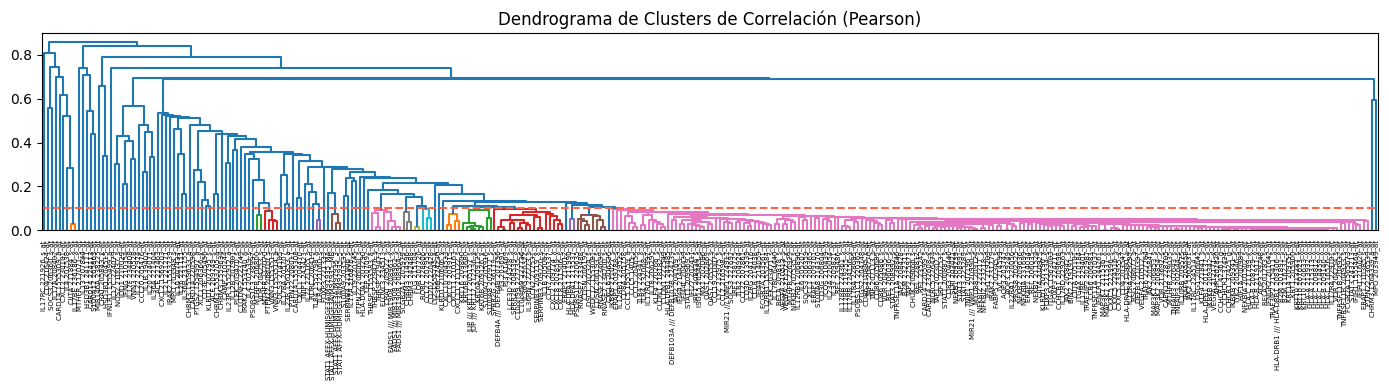


🔍 Total de clusters: 92
📊 Distribución:
Cluster
1       1
2       1
3       2
4       1
5       1
6       1
7       1
8       1
9       1
10      1
11      1
12      1
13      1
14      1
15      1
16      1
17      1
18      1
19      1
20      1
21      1
22      1
23      1
24      1
25      1
26      1
27      1
28      1
29      1
30      1
31      1
32      1
33      1
34      1
35      1
36      1
37      1
38      1
39      1
40      1
41      1
42      1
43      2
44      4
45      1
46      1
47      1
48      1
49      1
50      1
51      1
52      1
53      2
54      1
55      1
56      1
57      3
58      1
59      1
60      1
61      1
62      1
63      8
64      3
65      2
66      3
67      1
68      4
69      8
70     18
71      2
72      8
73    192
74      1
75      1
76      1
77      1
78      1
79      1
80      1
81      1
82      1
83      1
84      1
85      1
86      1
87      1
88      1
89      1
90      1
91      1
92      1
Name: count, dtype: int64

✅ Re

In [10]:
UMBRAL_CORR_CLUSTER = 0.90

corr_mat = X_num_scaled.corr().abs()
dist_mat = (1 - corr_mat).to_numpy().copy()
np.fill_diagonal(dist_mat, 0)

enlace = linkage(dist_mat[np.triu_indices(len(dist_mat), k=1)], method='average')

fig, ax = plt.subplots(figsize=(14, 4))
sch.dendrogram(enlace, labels=X_num_scaled.columns.tolist(),
               leaf_rotation=90, leaf_font_size=5,
               color_threshold=1 - UMBRAL_CORR_CLUSTER, ax=ax)
ax.axhline(y=1 - UMBRAL_CORR_CLUSTER, color='tomato', linestyle='--', linewidth=1.5)
ax.set_title('Dendrograma de Clusters de Correlación (Pearson)')
plt.tight_layout()
plt.show()

etiquetas_cluster = fcluster(enlace, t=1 - UMBRAL_CORR_CLUSTER, criterion='distance')
cluster_df = pd.DataFrame({'Variable': X_num_scaled.columns, 'Cluster': etiquetas_cluster})
cluster_df = cluster_df.sort_values('Cluster')

print(f'\n🔍 Total de clusters: {cluster_df["Cluster"].nunique()}')
print(f'📊 Distribución:')
print(cluster_df['Cluster'].value_counts().sort_index())

# ⚠️ CAMBIO CRÍTICO: usar VARIANZA
representantes = []
print('\n✅ Representante por cluster (criterio: MAYOR VARIANZA):')
for cluster_id in sorted(cluster_df['Cluster'].unique()):
    vars_cluster = cluster_df[cluster_df['Cluster'] == cluster_id]['Variable'].tolist()
    if len(vars_cluster) == 1:
        representantes.append(vars_cluster[0])
        print(f'  Cluster {cluster_id:3d} → {vars_cluster[0]} (única)')
    else:
        varianzas = X_num_scaled[vars_cluster].var()
        mejor = varianzas.idxmax()
        representantes.append(mejor)
        print(f'  Cluster {cluster_id:3d} → {mejor} (var={varianzas[mejor]:.4f})')

COLS_NUM_REPR = representantes
print(f'\n📦 Representantes: {len(COLS_NUM_REPR)}')

### 12.4 Ranking Combinado MI+ANOVA *(con validación de divergencia Spearman)*  

**Justificación:** Se calculan dos rankings independientes sobre las variables representativas del clustering para identificar las más discriminativas respecto al target:

- **Mutual Information (`mutual_info_classif`)**: cuantifica la dependencia entre cada variable y el target sin asumir linealidad, capturando relaciones que Pearson no detectaría.
- **ANOVA F-test (`f_classif`)**: evalúa si las medias de cada variable difieren significativamente entre clases. Complemento lineal de MI.

**Proceso:**
1. Calcular MI y ANOVA sobre las variables representativas del clustering (`COLS_NUM_REPR`)
2. Crear rankings independientes (1 = mejor) para cada método
3. Combinar rankings promediando posiciones
4. Validar consistencia entre rankings con correlación de Spearman (umbral ≥ 0.70)
5. Seleccionar top 20%:
   - Si Spearman ≥ 0.70 → ranking combinado → `COLS_FILTER`
   - Si Spearman < 0.70 → rankings separados → `COLS_FILTER_MI` y `COLS_FILTER_ANOVA`

In [11]:
y_temp = df[VAR_OBJETIVO]

# PASO 1: Calcular MI y ANOVA sobre variables representativas del clustering
from scipy.stats import spearmanr

# Mutual Information
mi_scores = mutual_info_classif(
    X_num_scaled[COLS_NUM_REPR],
    y_temp,
    random_state=42
)
mi_df = pd.DataFrame({
    'Variable': COLS_NUM_REPR,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

# ANOVA F-test
f_scores, p_values_anova = f_classif(X_num_scaled[COLS_NUM_REPR], y_temp)
anova_df = pd.DataFrame({
    'Variable': COLS_NUM_REPR,
    'F_Score': f_scores,
    'p_value': p_values_anova
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

# PASO 2: Crear rankings (1 = mejor)
mi_df['Rank_MI'] = range(1, len(mi_df) + 1)
anova_df['Rank_ANOVA'] = range(1, len(anova_df) + 1)

# PASO 3: Combinar rankings
ranking_combined = mi_df[['Variable', 'Rank_MI']].merge(
    anova_df[['Variable', 'Rank_ANOVA']],
    on='Variable'
)
ranking_combined['Rank_Combined'] = (ranking_combined['Rank_MI'] + ranking_combined['Rank_ANOVA']) / 2
ranking_combined = ranking_combined.sort_values('Rank_Combined').reset_index(drop=True)

# PASO 4: Validar divergencia con correlación de Spearman
UMBRAL_DIVERGENCIA = 0.70
corr_spearman, _ = spearmanr(ranking_combined['Rank_MI'], ranking_combined['Rank_ANOVA'])

print(f'Correlación de Spearman entre rankings: {corr_spearman:.3f}')
print(f'Umbral de divergencia: {UMBRAL_DIVERGENCIA}')

# PASO 5: Seleccionar top 20%
TOP_PERCENTIL = 20
n_top = int(len(ranking_combined) * TOP_PERCENTIL / 100)
if corr_spearman >= UMBRAL_DIVERGENCIA:
    print('✅ Rankings consistentes → Usar ranking combinado')
    COLS_FILTER = ranking_combined.head(n_top)['Variable'].tolist()
    COLS_FILTER_MI = None
    COLS_FILTER_ANOVA = None
    print(f'\n📊 Variables seleccionadas (Top {TOP_PERCENTIL}%): {len(COLS_FILTER)}')
    print(ranking_combined.head(n_top))
else:
    print('⚠️ Alta divergencia → Usar MI y ANOVA por separado')
    COLS_FILTER = None
    COLS_FILTER_MI = mi_df.head(n_top)['Variable'].tolist()
    COLS_FILTER_ANOVA = anova_df.head(n_top)['Variable'].tolist()
    print(f'\n📊 MI top {TOP_PERCENTIL}%: {len(COLS_FILTER_MI)} variables')
    print(mi_df.head(n_top))
    print(f'\n📊 ANOVA top {TOP_PERCENTIL}%: {len(COLS_FILTER_ANOVA)} variables')
    print(anova_df.head(n_top))


Correlación de Spearman entre rankings: -0.250
Umbral de divergencia: 0.7
⚠️ Alta divergencia → Usar MI y ANOVA por separado

📊 MI top 20%: 18 variables
               Variable  MI_Score  Rank_MI
0     SOCS3 206360_s_at  0.313463        1
1        RORC 228806_at  0.305043        2
2     CIITA 211884_s_at  0.304516        3
3    IRAK2 1553740_a_at  0.301938        4
4       SOCS3 214105_at  0.292428        5
5        VNN3 220528_at  0.287806        6
6   CARD14 1555309_a_at  0.287373        7
7     MIR146A 238225_at  0.278004        8
8    CHRM3 1564339_a_at  0.276377        9
9        IL13 207844_at  0.275851       10
10      MTHFR 206800_at  0.275805       11
11    C1QTNF2 223749_at  0.275075       12
12       IL19 220745_at  0.270201       13
13      IL36A 221404_at  0.267330       14
14       IFNG 210354_at  0.264946       15
15       RORC 206419_at  0.264227       16
16       IL21 221271_at  0.263241       17
17      IL17A 208402_at  0.262152       18

📊 ANOVA top 20%: 18 variables

#### Chi-cuadrado (complementario) *(variables categóricas codificadas)*

**Justificación:** La prueba Chi-cuadrado mide la independencia estadística entre cada variable categórica y el target. Un p-value bajo rechaza la hipótesis de independencia, indicando que la variable aporta información discriminativa.

In [12]:
cols_cat_chi2 = [c for c in COLS_CATEGORICAS if c in df.columns]

if cols_cat_chi2:
    X_cat_enc = pd.DataFrame()
    for col in cols_cat_chi2:
        X_cat_enc[col] = LabelEncoder().fit_transform(df[col].astype(str))

    chi2_scores, p_values = chi2(X_cat_enc, y_temp)
    chi2_df = pd.DataFrame({
        'Variable':  cols_cat_chi2,
        'Chi2':      chi2_scores,
        'p-value':   p_values,
        'Significativa (p<0.05)': p_values < 0.05
    }).sort_values('Chi2', ascending=False)

    print('Chi-cuadrado — Variables Categóricas:')
    display(chi2_df)
else:
    print('No hay variables categóricas disponibles para Chi-cuadrado.')

Chi-cuadrado — Variables Categóricas:


,Variable,Chi2,p-value,Significativa (p<0.05)
1,Lesional/Non-lesional,332.549034,2.676768e-74,True
0,Sex,43.436617,4.379163e-11,True


### 12.5 Construcción de los Conjuntos

**Justificación:** Se crean hasta 4 matrices para comparar estrategias en el baseline:

1. **X_FULL** - Todas las variables filtradas por varianza (sin clustering ni ranking)
2. **X_CLUSTERING** - Variables representativas del clustering (elimina redundancia)
3. **X_FILTER** - Variables top 20% del ranking combinado MI+ANOVA (máxima discriminación solo si rankings son consistentes)
4. **X_FILTER_MI / X_FILTER_ANOVA** - Top 20% de cada ranking por separado (solo si hay alta divergencia entre rankings)

Estas matrices permiten evaluar el trade-off entre cantidad de información y reducción de dimensionalidad.

In [13]:
# Construcción de los conjuntos de variables numéricas

# 1. FULL: Todas las variables filtradas por varianza
X_FULL = X_num_scaled[COLS_NUM_FILTRADAS].copy()

# 2. CLUSTERING: Variables representativas (elimina redundancia)
X_CLUSTERING = X_num_scaled[COLS_NUM_REPR].copy()

print('📊 DIMENSIONES DE LOS CONJUNTOS:')
print(f'   X_FULL:       {X_FULL.shape}')
print(f'   X_CLUSTERING: {X_CLUSTERING.shape}')

# Los conjuntos 3 y 4. Dependen de divergencia.
if COLS_FILTER is not None:
    X_FILTER = X_num_scaled[COLS_FILTER].copy()
    print(f'   X_FILTER:     {X_FILTER.shape}')
else:
    X_FILTER_MI    = X_num_scaled[COLS_FILTER_MI].copy()
    X_FILTER_ANOVA = X_num_scaled[COLS_FILTER_ANOVA].copy()
    print(f'   X_FILTER_MI:    {X_FILTER_MI.shape}')
    print(f'   X_FILTER_ANOVA: {X_FILTER_ANOVA.shape}')

print()
print('✅ Todos los conjuntos están listos para concatenar con categóricas')

📊 DIMENSIONES DE LOS CONJUNTOS:
   X_FULL:       (624, 338)
   X_CLUSTERING: (624, 92)
   X_FILTER_MI:    (624, 18)
   X_FILTER_ANOVA: (624, 18)

✅ Todos los conjuntos están listos para concatenar con categóricas


---
## 13. Codificación de Variables Categóricas

**Justificación:** Los modelos de aprendizaje automático no operan sobre cadenas de texto. La elección del esquema de codificación afecta la cardinalidad y la interpretabilidad:

| Variable | Tipo | Esquema | Razón |
|---|---|---|---|
| Sex | Binaria (2 valores) | **Label Encoding** | Introduce solo 1 columna, orden sin significado real pero aceptable en binarias |

### 13.1 Label Encoding para categóricas binarias

In [14]:
# Identificar categóricas binarias (nunique == 2) y las de mayor cardinalidad
cols_cat_presentes = [c for c in COLS_CATEGORICAS if c in df.columns]
cols_binarias  = [c for c in cols_cat_presentes if df[c].nunique() == 2]
# Excluir 'Lesional/Non-lesional': solo se usa en Avance 1 para análisis exploratorio (PCA)
cols_nominales = [c for c in cols_cat_presentes if df[c].nunique() > 2 and c != 'Lesional/Non-lesional']

print(f'Categóricas binarias  (Label Encoding): {cols_binarias}')
print(f'Categóricas nominales (OneHot Encoding): {cols_nominales}')

# Aplicar Label Encoding
df_cat_encoded = pd.DataFrame(index=df.index)
le = LabelEncoder()
for col in cols_binarias:
    df_cat_encoded[col + '_LE'] = le.fit_transform(df[col].astype(str))
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nLabel Encoding aplicado.')

Categóricas binarias  (Label Encoding): ['Sex']
Categóricas nominales (OneHot Encoding): []
  Sex: {'F': np.int64(0), 'M': np.int64(1)}

Label Encoding aplicado.


### 13.2 OneHot Encoding para categóricas nominales con más de 2 categorías

In [15]:
if cols_nominales:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
    ohe_arr = ohe.fit_transform(df[cols_nominales].astype(str))
    ohe_cols = ohe.get_feature_names_out(cols_nominales)
    df_ohe = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df.index)
    df_cat_encoded = pd.concat([df_cat_encoded, df_ohe], axis=1)
    print(f'OneHot Encoding generó {df_ohe.shape[1]} columnas adicionales:')
    print(list(ohe_cols))
else:
    print('No hay variables nominales con más de 2 categorías.')

No hay variables nominales con más de 2 categorías.


### 13.3 Concatenación a los Conjuntos

**Justificación:** Las variables categóricas codificadas se agregan a cada una de las estrategias de feature engineering. Esto permite que el baseline compare estrategias con el mismo conjunto de variables categóricas pero diferente selección de numéricas.

In [16]:
# Concatenar categóricas codificadas a cada conjunto

# 1. FULL completo
X_FULL_completo = pd.concat([X_FULL, df_cat_encoded], axis=1)

# 2. CLUSTERING completo
X_CLUSTERING_completo = pd.concat([X_CLUSTERING, df_cat_encoded], axis=1)

print('📊 DIMENSIONES FINALES (con categóricas):')
print(f'   X_FULL_completo:       {X_FULL_completo.shape}')
print(f'   X_CLUSTERING_completo: {X_CLUSTERING_completo.shape}')

# 3. FILTER completo
if COLS_FILTER is not None:
    X_FILTER_completo = pd.concat([X_FILTER, df_cat_encoded], axis=1)
    print(f'   X_FILTER_completo:     {X_FILTER_completo.shape}')
else:
    X_FILTER_MI_completo    = pd.concat([X_FILTER_MI, df_cat_encoded], axis=1)
    X_FILTER_ANOVA_completo = pd.concat([X_FILTER_ANOVA, df_cat_encoded], axis=1)
    print(f'   X_FILTER_MI_completo:    {X_FILTER_MI_completo.shape}')
    print(f'   X_FILTER_ANOVA_completo: {X_FILTER_ANOVA_completo.shape}')

print()
print(f'   Variables categóricas añadidas: {df_cat_encoded.shape[1]}')
print('✅ Todos los conjuntos completos están listos para modelado')

📊 DIMENSIONES FINALES (con categóricas):
   X_FULL_completo:       (624, 339)
   X_CLUSTERING_completo: (624, 93)
   X_FILTER_MI_completo:    (624, 19)
   X_FILTER_ANOVA_completo: (624, 19)

   Variables categóricas añadidas: 1
✅ Todos los conjuntos completos están listos para modelado


---
## 14. Escalamiento 

**Nota:** No se requiere escalamiento adicional. Las variables numéricas fueron escaladas en sección 12.2.

La variables Categóricas no requieren escalamiento.

---
## 15. Extracción de Características

La extracción de características crea nuevas variables (combinaciones lineales de las originales) que condensan la información en un espacio de menor dimensión. Es el paso final antes de construir las matrices para modelado.

**Nota**: No se aplican técnicas de reducción de dimensionalidad (PCA, FA u otras) en esta fase de Feature Engineering. Las variables corresponden a marcadores de expresión genética con significado biológico, por lo que cualquier transformación que combine variables en componentes o factores latentes sacrifica la interpretabilidad clínica de los resultados.

El PCA fue utilizado con fines exploratorios en la fase de EDA (entrega anterior).

---
## 16. Matrices Finales para Modelado

Se generan **las matrices** finales listas para ser utilizadas en el siguiente avance (modelado). La cantidad de matrices depende de la divergencia entre rankings MI+ANOVA:

| Matriz | Descripción |
|---|---|
| `X_FULL_completo` | Todas las variables filtradas por varianza + categóricas codificadas |
| `X_CLUSTERING_completo` | Variables representativas por clustering de Pearson + categóricas codificadas |
| `X_FILTER_completo` | Top 20% ranking combinado MI+ANOVA + categóricas codificadas *(si los rankings son consistentes)* |
| `X_FILTER_MI_completo` | Top 20% ranking MI + categóricas codificadas *(si existe alta divergencia)* |
| `X_FILTER_ANOVA_completo` | Top 20% ranking ANOVA + categóricas codificadas *(si existe alta divergencia)* |
| `y` | Target codificado (0/1) |

### 16.1 Generar y verificar las matrices

In [17]:
# Target vector
y = pd.Series(y_temp, index=df.index, name=VAR_OBJETIVO)

print('=== MATRICES FINALES PARA MODELADO ===\n')
print(f'   X_FULL_completo:       {X_FULL_completo.shape}')
print(f'   X_CLUSTERING_completo: {X_CLUSTERING_completo.shape}')

if COLS_FILTER is not None:
    print(f'   X_FILTER_completo:     {X_FILTER_completo.shape}')
else:
    print(f'   X_FILTER_MI_completo:    {X_FILTER_MI_completo.shape}')
    print(f'   X_FILTER_ANOVA_completo: {X_FILTER_ANOVA_completo.shape}')

print(f'\n   y (target): {y.shape} — clases: {dict(pd.Series(y).value_counts())}')

# Verificar ausencia de NaN
matrices = {
    'X_FULL_completo': X_FULL_completo,
    'X_CLUSTERING_completo': X_CLUSTERING_completo
}
if COLS_FILTER is not None:
    matrices['X_FILTER_completo'] = X_FILTER_completo
else:
    matrices['X_FILTER_MI_completo'] = X_FILTER_MI_completo
    matrices['X_FILTER_ANOVA_completo'] = X_FILTER_ANOVA_completo

for nombre, mat in matrices.items():
    nans = mat.isna().sum().sum()
    print(f'   Valores NaN en {nombre}: {nans}')

=== MATRICES FINALES PARA MODELADO ===

   X_FULL_completo:       (624, 339)
   X_CLUSTERING_completo: (624, 93)
   X_FILTER_MI_completo:    (624, 19)
   X_FILTER_ANOVA_completo: (624, 19)

   y (target): (624,) — clases: {'Psoriasis': np.int64(449), 'Healthy': np.int64(175)}
   Valores NaN en X_FULL_completo: 0
   Valores NaN en X_CLUSTERING_completo: 0
   Valores NaN en X_FILTER_MI_completo: 0
   Valores NaN en X_FILTER_ANOVA_completo: 0


In [18]:
# Guardar matrices finales
DIR_OUT = "D:/Proyectos/Python/pi_psoriasis/data/features"

y.to_csv(f'{DIR_OUT}/y_target.csv')
X_FULL_completo.to_csv(f'{DIR_OUT}/X_FULL_completo.csv')
X_CLUSTERING_completo.to_csv(f'{DIR_OUT}/X_CLUSTERING_completo.csv')

if COLS_FILTER is not None:
    X_FILTER_completo.to_csv(f'{DIR_OUT}/X_FILTER_completo.csv')
else:
    X_FILTER_MI_completo.to_csv(f'{DIR_OUT}/X_FILTER_MI_completo.csv')
    X_FILTER_ANOVA_completo.to_csv(f'{DIR_OUT}/X_FILTER_ANOVA_completo.csv')

print('✅ Matrices guardadas en:', DIR_OUT)

✅ Matrices guardadas en: D:/Proyectos/Python/pi_psoriasis/data/features


---
## 17. Conclusiones — Fase de Preparación de Datos (CRISP-ML)

En el marco **CRISP-ML(Q)**, esta sección corresponde a la fase de *Data Preparation*, que transforma los datos crudos en representaciones adecuadas para los algoritmos de modelado. A continuación se sintetizan las decisiones tomadas y su justificación metodológica:

### 17.1 Selección de características (Sección 11)

| Método | Variables de entrada | Variables de salida | Justificación |
|---|---|---|---|
| `VarianceThreshold` | Todas las numéricas | `COLS_NUM_FILTRADAS` | Elimina variables sin variabilidad informativa |
| Correlación + clustering jerárquico | `COLS_NUM_FILTRADAS` | `COLS_NUM_REPR` | Elimina redundancia entre variables altamente correlacionadas |
| `mutual_info_classif` | `COLS_NUM_REPR` + categóricas | Ranking unificado | Detecta dependencias lineales y no lineales |
| Chi-cuadrado | Categóricas codificadas | Ranking por independencia | Identifica asociación estadística con el target |
| ANOVA F-test | Numéricas representantes | Ranking por diferencia de medias | Complemento lineal de MI para variables numéricas |

Los conjuntos resultantes pueden ser 3 o 4 dependiendo de la divergencia entre rankings.

### 17.2 Transformaciones y preprocesamiento (Secciones 12–14)

- **Yeo-Johnson** (Sección 12): Aplicada a variables con `|sesgo| > 1.0`. Mejora la simetría de la distribución sin requerir que los valores sean positivos, lo que es necesario en datos de expresión génica que pueden estar en escala logarítmica.
- **Label Encoding** (Sección 13.1): Para variables categóricas binarias. Un solo bit de información sin orden artificial.
- **OneHot Encoding** (Sección 13.2): Para variables nominales con más de 2 categorías (Race). Evita introducir orden inexistente entre categorías.
- **StandardScaler** (Sección 12.2): Aplicado *después* del Filtrado por Varianza sobre los datos previamente transformados con Yeo-Johnson.

### 17.3 Extracción de características (Sección 15)

Debido a que las variables corresponden a marcadores de expresión genomica, no se aplica ninguna técnica de reducción de dimensionalidad para no perder interpretabilidad.

### 17.4 Matrices entregables para modelado (Sección 16)

Se generaron entre 3 y 4 matrices según la consistencia entre rankings MI y ANOVA:

1. **X_FULL_completo**: Conserva todas las variables filtradas por varianza + categóricas codificadas. Sirve como referencia máxima de información para el baseline.
2. **X_CLUSTERING_completo**: Variables representativas del clustering de Pearson + categóricas codificadas. Conjunto con reducida redundancia entre variables altamente correlacionadas.
3. **X_FILTER_completo**: Top 20% del ranking combinado MI+ANOVA sobre representantes del clustering + categóricas codificadas. Se genera si los rankings de MI y ANOVA son consistentes (Spearman ≥ 0.70).
4. **X_FILTER_MI_completo y X_FILTER_ANOVA_completo**: Top 20% de cada ranking por separado + categóricas codificadas. Se generan cuando los rankings de MI y ANOVA tiene alta divergencia (Spearman < 0.70).

### 17.5 Referencias

- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (2nd ed.). O'Reilly.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning. *JMLR*, 18(17), 1–5.
- IBM SPSS Statistics (2020). *Factor Analysis*. IBM Corp.
- Yeo, I. K., & Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. *Biometrika*, 87(4), 954–959.